In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/PCOS_data.csv')
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
df.head()

Shape: (465, 16)

Columns:
['Age (in Years)', 'Weight (in Kg)', 'Height (in Cm / Feet)', 'Can you tell us your blood group ?', 'After how many months do you get your periods?\n(select 1- if every month/regular)', 'Have you gained weight recently?', 'Do you have excessive body/facial hair growth ?', 'Are you noticing skin darkening recently?', 'Do have hair loss/hair thinning/baldness ?', 'Do you have pimples/acne on your face/jawline ?', 'Do you eat fast food regularly ?', 'Do you exercise on a regular basis ?', 'Have you been diagnosed with PCOS/PCOD?', 'Do you experience mood swings ?', 'Are your periods regular ?', 'How long does your period last ? (in Days)\nexample- 1,2,3,4.....']


,Age (in Years),Weight (in Kg),Height (in Cm / Feet),Can you tell us your blood group ?,After how many months do you get your periods?\n(select 1- if every month/regular),Have you gained weight recently?,Do you have excessive body/facial hair growth ?,Are you noticing skin darkening recently?,Do have hair loss/hair thinning/baldness ?,Do you have pimples/acne on your face/jawline ?,Do you eat fast food regularly ?,Do you exercise on a regular basis ?,Have you been diagnosed with PCOS/PCOD?,Do you experience mood swings ?,Are your periods regular ?,"How long does your period last ? (in Days)\nexample- 1,2,3,4....."
0,21,47.0,168.0,13,1,0,0,0,0,0,0,0,0,1,1,6
1,21,45.0,156.0,11,1,0,0,1,1,1,0,0,0,1,1,4
2,17,37.0,162.0,15,1,0,0,0,0,1,1,0,0,1,1,6
3,28,54.0,160.0,15,1,0,0,0,0,0,0,0,0,1,1,4
4,45,40.0,150.0,13,2,0,0,0,1,0,0,0,1,1,0,7


In [7]:
print(df.columns.tolist())
print(df['Have you been diagnosed with PCOS/PCOD?'].value_counts())


['Age (in Years)', 'Weight (in Kg)', 'Height (in Cm / Feet)', 'Can you tell us your blood group ?', 'After how many months do you get your periods?\n(select 1- if every month/regular)', 'Have you gained weight recently?', 'Do you have excessive body/facial hair growth ?', 'Are you noticing skin darkening recently?', 'Do have hair loss/hair thinning/baldness ?', 'Do you have pimples/acne on your face/jawline ?', 'Do you eat fast food regularly ?', 'Do you exercise on a regular basis ?', 'Have you been diagnosed with PCOS/PCOD?', 'Do you experience mood swings ?', 'Are your periods regular ?', 'How long does your period last ? (in Days)\nexample- 1,2,3,4.....']
Have you been diagnosed with PCOS/PCOD?
0    363
1    102
Name: count, dtype: int64


In [27]:
# Rename target column to something shorter
df = df.rename(columns={'Have you been diagnosed with PCOS/PCOD?': 'PCOS'})
df = df.rename(columns={'Have you gained weight recently?': 'Recent Weight Gain'})
df = df.rename(columns={'Can you tell us your blood group ?': 'Blood Group'})
df = df.rename(columns={'Do you exercise on a regular basis ?': 'Regular Excersize'})
df = df.rename(columns={'Do you experience mood swings ?': 'Mood Swings'})
df = df.rename(columns={'Are your periods regular ?': 'Regular Periods'})
df = df.rename(columns={'Do you eat fast food regularly ?': 'Regular Fast Food'})
df = df.rename(columns={'Do you have pimples/acne on your face/jawline ?': 'Jaw/Face Acne/Pimples'})
df = df.rename(columns={'Do you have excessive body/facial hair growth ?': 'Excessive Hair Growth (Body/Facial)'})
df = df.rename(columns={'Do have hair loss/hair thinning/baldness ?': 'Hair Thinning/Baldness'})

# Check data types
print(df.dtypes)


Age (in Years)                                                                          int64
Weight (in Kg)                                                                        float64
Height (in Cm / Feet)                                                                 float64
Blood Group                                                                             int64
After how many months do you get your periods?\n(select 1- if every month/regular)      int64
Recent Weight Gain                                                                      int64
Excessive Hair Growth (Body/Facial)                                                     int64
Are you noticing skin darkening recently?                                               int64
Hair Thinning/Baldness                                                                  int64
Jaw/Face Acne/Pimples                                                                   int64
Regular Fast Food                                           

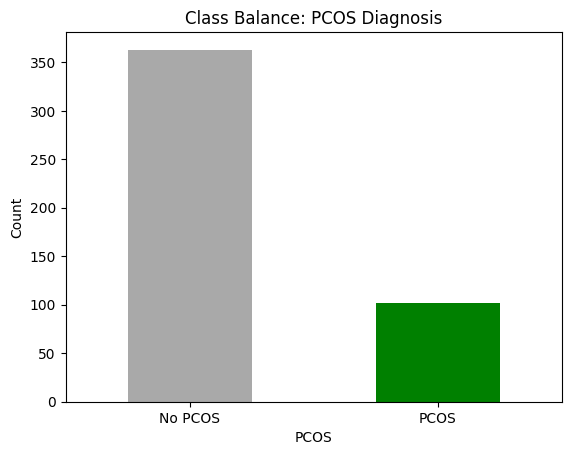

In [19]:
# Plot class balance
df['PCOS'].value_counts().plot(kind='bar', color=['darkgrey', 'green'])
plt.title('Class Balance: PCOS Diagnosis')
plt.xticks([0, 1], ['No PCOS', 'PCOS'], rotation=0)
plt.ylabel('Count')
plt.show()


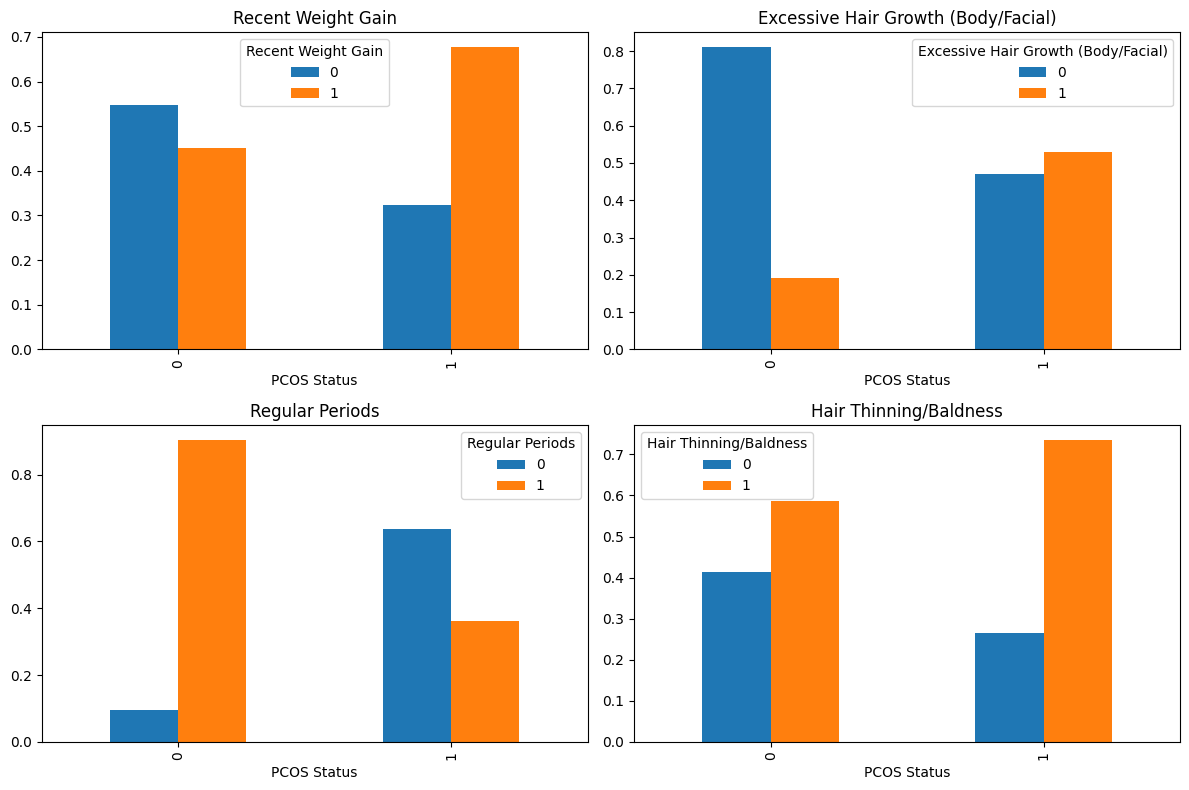

In [29]:
symptom_cols = ['Recent Weight Gain',
                'Excessive Hair Growth (Body/Facial)',
                'Regular Periods',
                'Hair Thinning/Baldness']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), symptom_cols):
    df.groupby('PCOS')[col].value_counts(normalize=True).unstack().plot(kind='bar', ax=ax)
    ax.set_title(col[:40])
    ax.set_xlabel('PCOS Status')
plt.tight_layout()
plt.show()


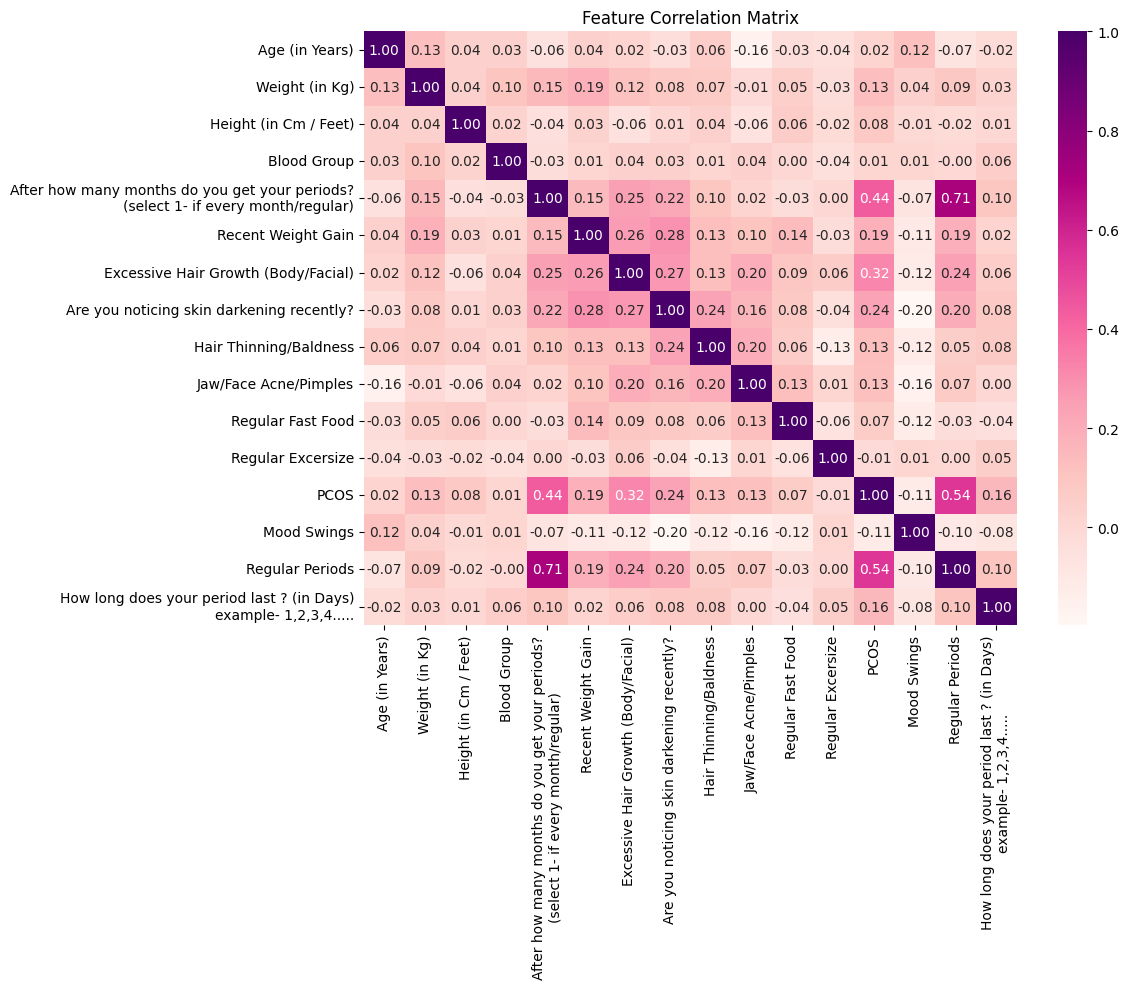

In [30]:
# Correlation heatmap
# First encode any text columns to numeric
df_encoded = df.apply(lambda col: pd.factorize(col)[0])
plt.figure(figsize=(12, 10))
sns.heatmap(df_encoded.corr(), annot=True, fmt=".2f", cmap="RdPu")
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()
# Look for which features correlate most with PCOS column



In [31]:
corr = df_encoded.corr()
print(corr['PCOS'].sort_values(ascending=False))

PCOS                                                                                  1.000000
Regular Periods                                                                       0.544719
After how many months do you get your periods?\n(select 1- if every month/regular)    0.436040
Excessive Hair Growth (Body/Facial)                                                   0.318353
Are you noticing skin darkening recently?                                             0.236946
Recent Weight Gain                                                                    0.185950
How long does your period last ? (in Days)\nexample- 1,2,3,4.....                     0.157911
Weight (in Kg)                                                                        0.130807
Hair Thinning/Baldness                                                                0.126575
Jaw/Face Acne/Pimples                                                                 0.125437
Height (in Cm / Feet)                             

In [32]:
# inspecting secondary dataset

df_second = pd.read_csv('../data/PCOS_data_second.csv')
print(df_second.shape)
print(df_second.columns.tolist())

(541, 45)
['Sl. No', 'Patient File No.', 'PCOS (Y/N)', ' Age (yrs)', 'Weight (Kg)', 'Height(Cm) ', 'BMI', 'Blood Group', 'Pulse rate(bpm) ', 'RR (breaths/min)', 'Hb(g/dl)', 'Cycle(R/I)', 'Cycle length(days)', 'Marraige Status (Yrs)', 'Pregnant(Y/N)', 'No. of aborptions', '  I   beta-HCG(mIU/mL)', 'II    beta-HCG(mIU/mL)', 'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH', 'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio', 'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)', 'PRG(ng/mL)', 'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)', 'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle No. (R)', 'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'Endometrium (mm)', 'Unnamed: 44']


In [34]:
# Drop junk columns
df_second = df_second.drop(columns=['Sl. No', 'Patient File No.', 'Unnamed: 44'])

# Rename target to match your convention
df_second = df_second.rename(columns={'PCOS (Y/N)': 'PCOS'})

# Check class balance
print(df_second['PCOS'].value_counts())

# Check missing values
print(df_second.isnull().sum().sort_values(ascending=False).head(10))

PCOS
0    364
1    177
Name: count, dtype: int64
Marraige Status (Yrs)    1
Fast food (Y/N)          1
PCOS                     0
PRL(ng/mL)               0
Vit D3 (ng/mL)           0
PRG(ng/mL)               0
RBS(mg/dl)               0
Weight gain(Y/N)         0
hair growth(Y/N)         0
Skin darkening (Y/N)     0
dtype: int64


In [36]:
df_second = df_second.dropna(subset=['Marraige Status (Yrs)', 'Fast food (Y/N)'])
print(f'Secondary rows after cleaning: {len(df_second)}')  # should be 539

Secondary rows after cleaning: 539


In [37]:
# Model A: symptom-only columns (mirrors what patient enters in your app)
symptom_cols = [
    ' Age (yrs)', 'Weight (Kg)', 'Height(Cm) ', 'BMI',
    'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)',
    'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)',
    'Reg.Exercise(Y/N)', 'Cycle(R/I)', 'Cycle length(days)'
]

# Model B: symptom + clinical (what a clinician version would use)
clinical_cols = symptom_cols + [
    'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH', 'AMH(ng/mL)',
    'TSH (mIU/L)', 'PRL(ng/mL)', 'Waist:Hip Ratio',
    'Follicle No. (L)', 'Follicle No. (R)',
    'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)'
]

X_symptom = df_second[symptom_cols]
X_clinical = df_second[clinical_cols]
y = df_second['PCOS']

print(f'Symptom features: {len(symptom_cols)}')
print(f'Clinical features: {len(clinical_cols)}')

Symptom features: 13
Clinical features: 24


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check if mood swings issue exists here too (it shouldn't - Kerala doesn't have it)
# Instead check your overlapping symptom correlations
corr = df_second[symptom_cols + ['PCOS']].apply(pd.to_numeric, errors='coerce').corr()
print(corr['PCOS'].sort_values(ascending=False))

PCOS                    1.000000
Skin darkening (Y/N)    0.481768
hair growth(Y/N)        0.466930
Weight gain(Y/N)        0.443652
Cycle(R/I)              0.402312
Fast food (Y/N)         0.381772
Pimples(Y/N)            0.288609
Weight (Kg)             0.210280
BMI                     0.196479
Hair loss(Y/N)          0.177458
Reg.Exercise(Y/N)       0.069481
Height(Cm)              0.066361
 Age (yrs)             -0.172436
Cycle length(days)     -0.183781
Name: PCOS, dtype: float64


In [48]:
# ── MODEL A: Patient-facing, symptom-only ──

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

symptom_cols_A = [
    'Age (in Years)',
    'Weight (in Kg)',
    'Height (in Cm / Feet)',
    'Blood Group',
    'After how many months do you get your periods?\n(select 1- if every month/regular)',
    'Recent Weight Gain',
    'Excessive Hair Growth (Body/Facial)',
    'Are you noticing skin darkening recently?',
    'Hair Thinning/Baldness',
    'Jaw/Face Acne/Pimples',
    'Regular Fast Food',
    'Regular Excersize',
    'Mood Swings',
    'Regular Periods',
    'How long does your period last ? (in Days)\nexample- 1,2,3,4.....'
]

X_A = df[symptom_cols_A]
y_A = df['PCOS']

X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(
    X_A, y_A, test_size=0.2, random_state=42, stratify=y_A)

sm_A = SMOTE(random_state=42)
X_train_A_res, y_train_A_res = sm_A.fit_resample(X_train_A, y_train_A)

xgb_A = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_A.fit(X_train_A_res, y_train_A_res)

print("=== Model A: Symptom Only (2023 dataset) ===")
print(classification_report(y_test_A, xgb_A.predict(X_test_A),
      target_names=['No PCOS', 'PCOS']))
print(f'AUC-ROC: {roc_auc_score(y_test_A, xgb_A.predict_proba(X_test_A)[:,1]):.3f}')

/Users/sanjnasood/Documents/GitHub/pcos-screening-tool/venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


=== Model A: Symptom Only (2023 dataset) ===
              precision    recall  f1-score   support

     No PCOS       0.85      0.90      0.87        73
        PCOS       0.53      0.40      0.46        20

    accuracy                           0.80        93
   macro avg       0.69      0.65      0.67        93
weighted avg       0.78      0.80      0.78        93

AUC-ROC: 0.699


In [45]:
print(df.columns.tolist())


['Age (in Years)', 'Weight (in Kg)', 'Height (in Cm / Feet)', 'Blood Group', 'After how many months do you get your periods?\n(select 1- if every month/regular)', 'Recent Weight Gain', 'Excessive Hair Growth (Body/Facial)', 'Are you noticing skin darkening recently?', 'Hair Thinning/Baldness', 'Jaw/Face Acne/Pimples', 'Regular Fast Food', 'Regular Excersize', 'PCOS', 'Mood Swings', 'Regular Periods', 'How long does your period last ? (in Days)\nexample- 1,2,3,4.....']


In [ ]:
for col in clinical_cols_B:
    bad_count = (df_second_original[col].astype(str).str.contains('#NAME?', regex=False)).sum()
    if bad_count > 0:
        print(f"{col}: {bad_count} bad values")

In [55]:
# ── MODEL B: Symptom + Clinical (Kerala dataset) ──

symptom_cols_B = [
    ' Age (yrs)', 'Weight (Kg)', 'Height(Cm) ', 'BMI',
    'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)',
    'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)',
    'Reg.Exercise(Y/N)', 'Cycle(R/I)', 'Cycle length(days)'
]

clinical_cols_B = symptom_cols_B + [
    'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH', 'AMH(ng/mL)',
    'TSH (mIU/L)', 'PRL(ng/mL)', 'Waist:Hip Ratio',
    'Follicle No. (L)', 'Follicle No. (R)',
    'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)'
]

# Check every clinical column for non-numeric values
for col in clinical_cols_B:
    # Try converting to float and catch what fails
    errors = pd.to_numeric(df_second[col], errors='coerce')
    bad_rows = df_second[errors.isna() & df_second[col].notna()]
    if len(bad_rows) > 0:
        print(f"\nColumn: {col}")
        print(bad_rows[col].unique())
# X_B = df_second[clinical_cols_B]
# y_B = df_second['PCOS']

# X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
#     X_B, y_B, test_size=0.2, random_state=42, stratify=y_B)

# sm_B = SMOTE(random_state=42)
# X_train_B_res, y_train_B_res = sm_B.fit_resample(X_train_B, y_train_B)

# xgb_B = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
# xgb_B.fit(X_train_B_res, y_train_B_res)

# print("=== Model B: Symptom + Clinical (Kerala dataset) ===")
# print(classification_report(y_test_B, xgb_B.predict(X_test_B),
#       target_names=['No PCOS', 'PCOS']))
# print(f'AUC-ROC: {roc_auc_score(y_test_B, xgb_B.predict_proba(X_test_B)[:,1]):.3f}')